# ECE 570 Project - Checkpoint 2 (Google Colab / Tesla T4)

This notebook is designed for **Google Colab with GPU runtime**.

Recommended Colab setup:
- `Runtime` -> `Change runtime type`
- Hardware accelerator: `GPU`
- Expected GPU: `Tesla T4`

Recommended run order:
1. Run the **quick ablation** first: `full_ft` vs `LoRA` vs `PiSSA-LoRA` on `5k` images.
2. Run the **large-data suite** second: `LoRA` vs `PiSSA-LoRA` on `50k` train images.
3. Use the quick suite if you need a fast result, and the large suite if you want stronger evidence.


## Colab Notes

- This notebook saves outputs to `/content/ece570_cp2_outputs`.
- Large-scale `full_ft` is disabled by default because it is much slower and less memory-friendly than adapter tuning.
- If T4 memory becomes tight, reduce `micro_batch_size` from `16` to `8` and increase `grad_accum_steps` from `2` to `4`.
- If runtime is tight, reduce large-suite `val_size` from `10000` to `2000` first before shrinking `train_size`.

Optional Google Drive save path:
```python
# from google.colab import drive
# drive.mount('/content/drive')
# OUTPUT_DIR = Path('/content/drive/MyDrive/ece570_cp2_outputs')
```


In [ ]:
!pip install -q -U torch torchvision transformers datasets peft accelerate pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 124.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import gc
import random
import warnings
from contextlib import nullcontext
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from IPython.display import display
from peft import LoraConfig, get_peft_model
from torch.utils.data import DataLoader
from transformers import ViTForImageClassification, ViTImageProcessor

warnings.filterwarnings("ignore", message=".*HF_TOKEN.*")
warnings.filterwarnings("ignore", message=".*use_return_dict.*")

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")


In [ ]:
torch.cuda.is_available()

True

In [ ]:
MODEL_NAME = "google/vit-base-patch16-224-in21k"
NUM_LABELS = 10
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_FP16 = DEVICE == "cuda"
OUTPUT_DIR = Path("/content/ece570_cp2_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("device:", DEVICE)
print("gpu:", torch.cuda.get_device_name(0))

if DEVICE != "cuda":
    raise RuntimeError("This notebook is intended for a Colab GPU runtime. Switch runtime to GPU and re-run.")

print("device:", DEVICE)
print("gpu:", torch.cuda.get_device_name(0))
print("output_dir:", OUTPUT_DIR)


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


@dataclass
class ExperimentConfig:
    name: str
    train_size: int
    val_size: int
    epochs: int = 1
    micro_batch_size: int = 16
    eval_batch_size: int = 64
    grad_accum_steps: int = 2
    lr_full_ft: float = 5e-5
    lr_lora: float = 2e-4
    weight_decay: float = 0.01
    rank: int = 8
    alpha: int = 16
    dropout: float = 0.05
    num_workers: int = 2
    log_every: int = 100
    max_train_batches: Optional[int] = None
    max_eval_batches: Optional[int] = None


RUN_QUICK_SUITE = True
RUN_LARGE_SUITE = True
RUN_FULL_FT_IN_QUICK = True
RUN_FULL_FT_IN_LARGE = False

QUICK_CONFIG = ExperimentConfig(
    name="quick_ablation",
    train_size=5000,
    val_size=1000,
    epochs=1,
    micro_batch_size=16,
    eval_batch_size=64,
    grad_accum_steps=2,
    log_every=50,
)

LARGE_CONFIG = ExperimentConfig(
    name="large_50k",
    train_size=50000,
    val_size=10000,
    epochs=1,
    micro_batch_size=16,
    eval_batch_size=64,
    grad_accum_steps=2,
    log_every=250,
)

print(asdict(QUICK_CONFIG))
print(asdict(LARGE_CONFIG))
set_seed(SEED)


device: cuda
gpu: Tesla T4
device: cuda
gpu: Tesla T4
output_dir: /content/ece570_cp2_outputs
{'name': 'quick_ablation', 'train_size': 5000, 'val_size': 1000, 'epochs': 1, 'micro_batch_size': 16, 'eval_batch_size': 64, 'grad_accum_steps': 2, 'lr_full_ft': 5e-05, 'lr_lora': 0.0002, 'weight_decay': 0.01, 'rank': 8, 'alpha': 16, 'dropout': 0.05, 'num_workers': 2, 'log_every': 50, 'max_train_batches': None, 'max_eval_batches': None}
{'name': 'large_50k', 'train_size': 50000, 'val_size': 10000, 'epochs': 1, 'micro_batch_size': 16, 'eval_batch_size': 64, 'grad_accum_steps': 2, 'lr_full_ft': 5e-05, 'lr_lora': 0.0002, 'weight_decay': 0.01, 'rank': 8, 'alpha': 16, 'dropout': 0.05, 'num_workers': 2, 'log_every': 250, 'max_train_batches': None, 'max_eval_batches': None}


In [ ]:
_CIFAR10 = None


def get_cifar10():
    global _CIFAR10
    if _CIFAR10 is None:
        _CIFAR10 = load_dataset("cifar10")
    return _CIFAR10


def parameter_summary(model) -> Dict[str, float]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {
        "trainable_params": trainable,
        "total_params": total,
        "trainable_pct": 100.0 * trainable / total,
    }


def make_dataloaders(image_processor, config: ExperimentConfig):
    ds = get_cifar10()
    train_ds = ds["train"].shuffle(seed=SEED).select(range(config.train_size))
    val_ds = ds["test"].shuffle(seed=SEED).select(range(config.val_size))

    def collate_fn(batch):
        images = [row["img"] for row in batch]
        labels = torch.tensor([row["label"] for row in batch], dtype=torch.long)
        inputs = image_processor(images=images, return_tensors="pt")
        inputs["labels"] = labels
        return inputs

    generator = torch.Generator()
    generator.manual_seed(SEED)

    train_loader = DataLoader(
        train_ds,
        batch_size=config.micro_batch_size,
        shuffle=True,
        generator=generator,
        collate_fn=collate_fn,
        num_workers=config.num_workers,
        pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=config.eval_batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=config.num_workers,
        pin_memory=True,
    )
    return train_loader, val_loader


def build_model(method: str, config: ExperimentConfig):
    model = ViTForImageClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        ignore_mismatched_sizes=True,
    )
    if method == "full_ft":
        return model.to(DEVICE), "full_ft"

    init_candidates = [True] if method == "lora" else ["pissa_niter_4", "pissa"]
    last_err = None
    for init in init_candidates:
        try:
            lora_cfg = LoraConfig(
                r=config.rank,
                lora_alpha=config.alpha,
                lora_dropout=config.dropout,
                bias="none",
                target_modules=["query", "value"],
                modules_to_save=["classifier"],
                task_type="SEQ_CLS",
                init_lora_weights=init,
            )
            peft_model = get_peft_model(model, lora_cfg)
            return peft_model.to(DEVICE), str(init)
        except Exception as exc:
            last_err = exc
    raise RuntimeError(f"Failed to build {method}: {last_err}")


In [ ]:
def amp_context():
    if USE_FP16 and DEVICE == "cuda":
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


def evaluate(model, dataloader, max_eval_batches: Optional[int] = None) -> Dict[str, float]:
    model.eval()
    total_correct = 0
    total_items = 0
    losses = []

    with torch.no_grad():
        for step, batch in enumerate(dataloader, start=1):
            pixel_values = batch["pixel_values"].to(DEVICE, non_blocking=True)
            labels = batch["labels"].to(DEVICE, non_blocking=True)
            with amp_context():
                out = model(pixel_values=pixel_values, labels=labels)
            losses.append(float(out.loss.detach().cpu()))
            preds = out.logits.argmax(dim=-1)
            total_correct += (preds == labels).sum().item()
            total_items += labels.size(0)
            if max_eval_batches is not None and step >= max_eval_batches:
                break

    return {
        "loss": float(np.mean(losses)),
        "acc": total_correct / total_items,
    }


def train_model(model, train_loader, config: ExperimentConfig, method: str) -> Dict[str, float]:
    lr = config.lr_full_ft if method == "full_ft" else config.lr_lora
    optimizer = torch.optim.AdamW(
        (p for p in model.parameters() if p.requires_grad),
        lr=lr,
        weight_decay=config.weight_decay,
    )
    scaler = torch.cuda.amp.GradScaler(enabled=USE_FP16)

    history = []
    optimizer.zero_grad(set_to_none=True)

    for epoch in range(1, config.epochs + 1):
        model.train()
        batch_losses = []
        last_step = 0

        for step, batch in enumerate(train_loader, start=1):
            last_step = step
            pixel_values = batch["pixel_values"].to(DEVICE, non_blocking=True)
            labels = batch["labels"].to(DEVICE, non_blocking=True)

            with amp_context():
                out = model(pixel_values=pixel_values, labels=labels)
                loss = out.loss / config.grad_accum_steps

            scaler.scale(loss).backward()
            batch_losses.append(float((loss.detach() * config.grad_accum_steps).cpu()))

            if step % config.grad_accum_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

            if step % config.log_every == 0:
                print(
                    f"epoch {epoch:02d} | step {step:04d} | avg loss {np.mean(batch_losses[-config.log_every:]):.4f}",
                    flush=True,
                )

            if config.max_train_batches is not None and step >= config.max_train_batches:
                break

        if last_step % config.grad_accum_steps != 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        epoch_loss = float(np.mean(batch_losses))
        history.append({"epoch": epoch, "train_loss": epoch_loss, "lr": lr})
        print(f"epoch {epoch:02d} | avg train loss {epoch_loss:.4f}", flush=True)

    return history[-1]


In [ ]:
METHOD_LABELS = {
    "full_ft": "Full FT",
    "lora": "LoRA",
    "pissa_lora": "PiSSA-LoRA",
}


def methods_for_suite(include_full_ft: bool) -> List[str]:
    methods = ["lora", "pissa_lora"]
    if include_full_ft:
        methods.insert(0, "full_ft")
    return methods


def run_experiment(method: str, config: ExperimentConfig, image_processor) -> Dict[str, float]:
    set_seed(SEED)
    train_loader, val_loader = make_dataloaders(image_processor, config)
    model, init_used = build_model(method, config)
    params = parameter_summary(model)
    lr = config.lr_full_ft if method == "full_ft" else config.lr_lora

    print(f"\n[{METHOD_LABELS[method]}] suite={config.name} | lr={lr} | init={init_used}", flush=True)
    print(
        f"trainable params: {params['trainable_params']:,} / {params['total_params']:,} ({params['trainable_pct']:.4f}%)",
        flush=True,
    )

    before = evaluate(model, val_loader, max_eval_batches=config.max_eval_batches)
    train_stats = train_model(model, train_loader, config, method)
    after = evaluate(model, val_loader, max_eval_batches=config.max_eval_batches)

    result = {
        "suite": config.name,
        "method": method,
        "method_label": METHOD_LABELS[method],
        "init_used": init_used,
        "train_size": config.train_size,
        "val_size": config.val_size,
        "epochs": config.epochs,
        "micro_batch_size": config.micro_batch_size,
        "eval_batch_size": config.eval_batch_size,
        "grad_accum_steps": config.grad_accum_steps,
        "effective_batch_size": config.micro_batch_size * config.grad_accum_steps,
        "lr": lr,
        "weight_decay": config.weight_decay,
        "max_train_batches": config.max_train_batches,
        "max_eval_batches": config.max_eval_batches,
        **params,
        "val_loss_before": before["loss"],
        "val_acc_before": before["acc"],
        "train_loss_last": train_stats["train_loss"],
        "val_loss_after": after["loss"],
        "val_acc_after": after["acc"],
    }

    del model
    del train_loader
    del val_loader
    gc.collect()
    torch.cuda.empty_cache()
    return result


def run_suite(config: ExperimentConfig, include_full_ft: bool = False) -> pd.DataFrame:
    image_processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
    methods = methods_for_suite(include_full_ft)
    rows = []

    for method in methods:
        rows.append(run_experiment(method, config, image_processor))
        partial_df = pd.DataFrame(rows)
        partial_df.to_csv(OUTPUT_DIR / f"{config.name}_partial.csv", index=False)

    df = pd.DataFrame(rows).sort_values("val_acc_after", ascending=False).reset_index(drop=True)
    df.to_csv(OUTPUT_DIR / f"{config.name}_results.csv", index=False)
    display(df.round(4))
    return df


def plot_suite(df: pd.DataFrame, title: str):
    if df is None or df.empty:
        print("No results to plot.")
        return

    order = df.sort_values("val_acc_after", ascending=False)
    colors = {
        "Full FT": "#234B6D",
        "LoRA": "#2B6CB0",
        "PiSSA-LoRA": "#C05621",
    }

    plt.figure(figsize=(8, 4.5))
    bars = plt.bar(
        order["method_label"],
        order["val_acc_after"],
        color=[colors[label] for label in order["method_label"]],
    )
    plt.ylim(max(0.0, order["val_acc_after"].min() - 0.05), min(1.0, order["val_acc_after"].max() + 0.03))
    plt.ylabel("Validation Accuracy")
    plt.title(title)
    plt.grid(axis="y", alpha=0.2)
    for bar, value in zip(bars, order["val_acc_after"]):
        plt.text(bar.get_x() + bar.get_width() / 2, value + 0.002, f"{value:.3f}", ha="center")
    plt.show()


## Run 1: Quick Ablation

This is the fastest slide-ready result.

- Dataset: `5k train / 1k val`
- Methods: `Full FT`, `LoRA`, `PiSSA-LoRA`
- Purpose: reproduce checkpoint 1 setup, but add the missing standard LoRA baseline.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

...

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



[PiSSA-LoRA] suite=quick_ablation | lr=0.0002 | init=pissa_niter_4
trainable params: 302,602 / 86,108,948 (0.3514%)


/tmp/ipykernel_6274/3456008997.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_FP16)


epoch 01 | step 0050 | avg loss 2.2300
epoch 01 | step 0100 | avg loss 2.0168
epoch 01 | step 0150 | avg loss 1.7563
epoch 01 | step 0200 | avg loss 1.4557
epoch 01 | step 0250 | avg loss 1.1373
epoch 01 | step 0300 | avg loss 0.8196
epoch 01 | avg train loss 1.5333


,suite,method,method_label,init_used,train_size,val_size,epochs,micro_batch_size,eval_batch_size,grad_accum_steps,...,max_train_batches,max_eval_batches,trainable_params,total_params,trainable_pct,val_loss_before,val_acc_before,train_loss_last,val_loss_after,val_acc_after
0,quick_ablation,pissa_lora,PiSSA-LoRA,pissa_niter_4,5000,1000,1,16,64,2,...,None,None,302602,86108948,0.3514,2.3286,0.07,1.5333,0.6549,0.964
1,quick_ablation,lora,LoRA,True,5000,1000,1,16,64,2,...,None,None,302602,86108948,0.3514,2.3286,0.07,1.5104,0.5902,0.962
2,quick_ablation,full_ft,Full FT,full_ft,5000,1000,1,16,64,2,...,None,None,85806346,85806346,100.0000,2.3286,0.07,1.0338,0.4180,0.945


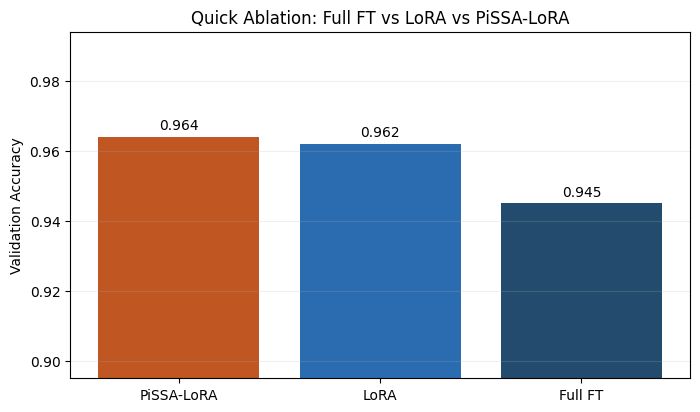

In [ ]:
quick_results = None
if RUN_QUICK_SUITE:
    quick_results = run_suite(QUICK_CONFIG, include_full_ft=RUN_FULL_FT_IN_QUICK)
    plot_suite(quick_results, "Quick Ablation: Full FT vs LoRA vs PiSSA-LoRA")
else:
    print("Quick suite skipped.")


## Run 2: Large-Data Suite

This is the Colab/T4 scale-up run.

- Default dataset: `50k train / 10k val`
- Default methods: `LoRA`, `PiSSA-LoRA`
- `Full FT` is disabled by default here because it is much slower and less practical for the deadline.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



[LoRA] suite=large_50k | lr=0.0002 | init=True
trainable params: 302,602 / 86,108,948 (0.3514%)


/tmp/ipykernel_6274/3456008997.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_FP16)


epoch 01 | step 0250 | avg loss 1.7109
epoch 01 | step 0500 | avg loss 0.4621
epoch 01 | step 0750 | avg loss 0.1787
epoch 01 | step 1000 | avg loss 0.1229
epoch 01 | step 1250 | avg loss 0.0913
epoch 01 | step 1500 | avg loss 0.0893
epoch 01 | step 1750 | avg loss 0.0794
epoch 01 | step 2000 | avg loss 0.0663
epoch 01 | step 2250 | avg loss 0.0625
epoch 01 | step 2500 | avg loss 0.0742
epoch 01 | step 2750 | avg loss 0.0590
epoch 01 | step 3000 | avg loss 0.0556
epoch 01 | avg train loss 0.2462


...

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



[PiSSA-LoRA] suite=large_50k | lr=0.0002 | init=pissa_niter_4
trainable params: 302,602 / 86,108,948 (0.3514%)


/tmp/ipykernel_6274/3456008997.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_FP16)


epoch 01 | step 0250 | avg loss 1.7285
epoch 01 | step 0500 | avg loss 0.5127
epoch 01 | step 0750 | avg loss 0.1814
epoch 01 | step 1000 | avg loss 0.1169
epoch 01 | step 1250 | avg loss 0.0932
epoch 01 | step 1500 | avg loss 0.0850
epoch 01 | step 1750 | avg loss 0.0789
epoch 01 | step 2000 | avg loss 0.0674
epoch 01 | step 2250 | avg loss 0.0589
epoch 01 | step 2500 | avg loss 0.0707
epoch 01 | step 2750 | avg loss 0.0528
epoch 01 | step 3000 | avg loss 0.0600
epoch 01 | avg train loss 0.2502


,suite,method,method_label,init_used,train_size,val_size,epochs,micro_batch_size,eval_batch_size,grad_accum_steps,...,max_train_batches,max_eval_batches,trainable_params,total_params,trainable_pct,val_loss_before,val_acc_before,train_loss_last,val_loss_after,val_acc_after
0,large_50k,pissa_lora,PiSSA-LoRA,pissa_niter_4,50000,10000,1,16,64,2,...,None,None,302602,86108948,0.3514,2.326,0.0739,0.2502,0.0573,0.9834
1,large_50k,lora,LoRA,True,50000,10000,1,16,64,2,...,None,None,302602,86108948,0.3514,2.326,0.0737,0.2462,0.0616,0.9822


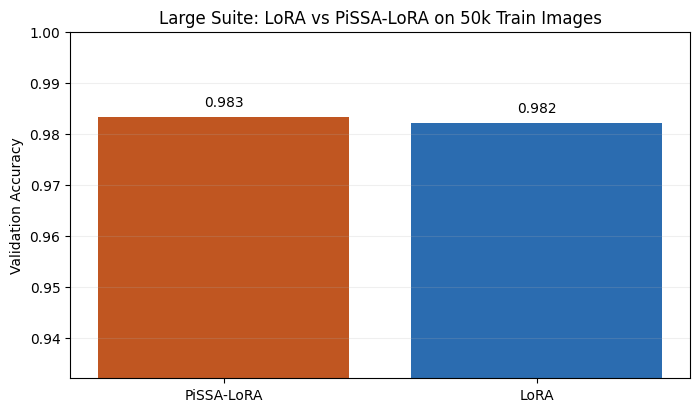

In [ ]:
large_results = None
if RUN_LARGE_SUITE:
    large_results = run_suite(LARGE_CONFIG, include_full_ft=RUN_FULL_FT_IN_LARGE)
    plot_suite(large_results, "Large Suite: LoRA vs PiSSA-LoRA on 50k Train Images")
else:
    print("Large suite skipped.")


In [ ]:
frames = [df for df in [quick_results, large_results] if isinstance(df, pd.DataFrame)]
if not frames:
    raise RuntimeError("Run at least one suite before combining results.")

all_results = pd.concat(frames, ignore_index=True)
all_results["setup"] = all_results["train_size"].astype(str) + " train / " + all_results["val_size"].astype(str) + " val"
all_results.to_csv(OUTPUT_DIR / "all_results.csv", index=False)

summary_cols = [
    "suite",
    "setup",
    "method_label",
    "init_used",
    "effective_batch_size",
    "trainable_pct",
    "val_acc_before",
    "val_acc_after",
    "train_loss_last",
]
display(all_results[summary_cols].round(4))
print("saved:", OUTPUT_DIR / "all_results.csv")


,suite,setup,method_label,init_used,effective_batch_size,trainable_pct,val_acc_before,val_acc_after,train_loss_last
0,quick_ablation,5000 train / 1000 val,PiSSA-LoRA,pissa_niter_4,32,0.3514,0.0700,0.9640,1.5333
1,quick_ablation,5000 train / 1000 val,LoRA,True,32,0.3514,0.0700,0.9620,1.5104
2,quick_ablation,5000 train / 1000 val,Full FT,full_ft,32,100.0000,0.0700,0.9450,1.0338
3,large_50k,50000 train / 10000 val,PiSSA-LoRA,pissa_niter_4,32,0.3514,0.0739,0.9834,0.2502
4,large_50k,50000 train / 10000 val,LoRA,True,32,0.3514,0.0737,0.9822,0.2462


saved: /content/ece570_cp2_outputs/all_results.csv


## Recommended Checkpoint 2 Usage

Fastest credible path:
- Keep `RUN_QUICK_SUITE = True`
- Keep `RUN_LARGE_SUITE = True`
- Keep `RUN_FULL_FT_IN_LARGE = False`

If you want exactly the 50k-scale adapter comparison:
- Leave `LARGE_CONFIG.train_size = 50000`
- Leave `LARGE_CONFIG.val_size = 10000`

If you hit runtime pressure on Colab:
- Change `LARGE_CONFIG.val_size` to `2000`
- Or set `LARGE_CONFIG.max_train_batches = 1000` for a partial but still meaningful run
- Or lower `micro_batch_size` to `8` and raise `grad_accum_steps` to `4`

Best slide-7 story if the large suite finishes:
- `At 5k images, LoRA and PiSSA-LoRA are similar.`
- `At 50k images, PiSSA-LoRA can be tested under a stronger data regime to see whether a consistent advantage emerges.`


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
OUTPUT_DIR = Path('/content/drive/MyDrive/ece570_cp2_outputs')

Mounted at /content/drive


In [ ]:
from datetime import datetime

RUN_EXTRA_LARGE_SUITE = True
RUN_FULL_FT_IN_EXTRA_LARGE = False  # keep adapter-only for T4 unless you want a very long run

EXTRA_LARGE_CONFIG = ExperimentConfig(
    name="extra_large_50k_e3_eb128",
    train_size=50000,
    val_size=10000,
    epochs=3,
    micro_batch_size=32,   # if T4 OOMs, change this to 16
    eval_batch_size=128,
    grad_accum_steps=4,    # effective batch size = 128
    lr_full_ft=5e-5,
    lr_lora=2e-4,
    weight_decay=0.01,
    rank=8,
    alpha=16,
    dropout=0.05,
    num_workers=2,
    log_every=250,
    max_train_batches=None,
    max_eval_batches=None,
)

print(asdict(EXTRA_LARGE_CONFIG))
print("effective batch =", EXTRA_LARGE_CONFIG.micro_batch_size * EXTRA_LARGE_CONFIG.grad_accum_steps)


{'name': 'extra_large_50k_e3_eb128', 'train_size': 50000, 'val_size': 10000, 'epochs': 3, 'micro_batch_size': 32, 'eval_batch_size': 128, 'grad_accum_steps': 4, 'lr_full_ft': 5e-05, 'lr_lora': 0.0002, 'weight_decay': 0.01, 'rank': 8, 'alpha': 16, 'dropout': 0.05, 'num_workers': 2, 'log_every': 250, 'max_train_batches': None, 'max_eval_batches': None}
effective batch = 128


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



[LoRA] suite=extra_large_50k_e3_eb128 | lr=0.0002 | init=True
trainable params: 302,602 / 86,108,948 (0.3514%)


/tmp/ipykernel_6274/3456008997.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_FP16)


epoch 01 | step 0250 | avg loss 2.0037
epoch 01 | step 0500 | avg loss 0.9813
epoch 01 | step 0750 | avg loss 0.3666
epoch 01 | step 1000 | avg loss 0.1913
epoch 01 | step 1250 | avg loss 0.1367
epoch 01 | step 1500 | avg loss 0.1052
epoch 01 | avg train loss 0.6091
epoch 02 | step 0250 | avg loss 0.0775
epoch 02 | step 0500 | avg loss 0.0730
epoch 02 | step 0750 | avg loss 0.0681
epoch 02 | step 1000 | avg loss 0.0573
epoch 02 | step 1250 | avg loss 0.0561
epoch 02 | step 1500 | avg loss 0.0568
epoch 02 | avg train loss 0.0643
epoch 03 | step 0250 | avg loss 0.0405
epoch 03 | step 0500 | avg loss 0.0321
epoch 03 | step 0750 | avg loss 0.0380
epoch 03 | step 1000 | avg loss 0.0443
epoch 03 | step 1250 | avg loss 0.0367
epoch 03 | step 1500 | avg loss 0.0349
epoch 03 | avg train loss 0.0377


...

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



[PiSSA-LoRA] suite=extra_large_50k_e3_eb128 | lr=0.0002 | init=pissa_niter_4
trainable params: 302,602 / 86,108,948 (0.3514%)


/tmp/ipykernel_6274/3456008997.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_FP16)


epoch 01 | step 0250 | avg loss 1.9676
epoch 01 | step 0500 | avg loss 1.0009
epoch 01 | step 0750 | avg loss 0.3719
epoch 01 | step 1000 | avg loss 0.1931
epoch 01 | step 1250 | avg loss 0.1344
epoch 01 | step 1500 | avg loss 0.1046
epoch 01 | avg train loss 0.6069
epoch 02 | step 0250 | avg loss 0.0692
epoch 02 | step 0500 | avg loss 0.0602
epoch 02 | step 0750 | avg loss 0.0566
epoch 02 | step 1000 | avg loss 0.0496
epoch 02 | step 1250 | avg loss 0.0485
epoch 02 | step 1500 | avg loss 0.0452
epoch 02 | avg train loss 0.0546
epoch 03 | step 0250 | avg loss 0.0289
epoch 03 | step 0500 | avg loss 0.0226
epoch 03 | step 0750 | avg loss 0.0268
epoch 03 | step 1000 | avg loss 0.0302
epoch 03 | step 1250 | avg loss 0.0249
epoch 03 | step 1500 | avg loss 0.0225
epoch 03 | avg train loss 0.0258


,suite,method,method_label,init_used,train_size,val_size,epochs,micro_batch_size,eval_batch_size,grad_accum_steps,...,max_train_batches,max_eval_batches,trainable_params,total_params,trainable_pct,val_loss_before,val_acc_before,train_loss_last,val_loss_after,val_acc_after
0,extra_large_50k_e3_eb128,pissa_lora,PiSSA-LoRA,pissa_niter_4,50000,10000,3,32,128,4,...,None,None,302602,86108948,0.3514,2.3261,0.0739,0.0258,0.0537,0.9854
1,extra_large_50k_e3_eb128,lora,LoRA,True,50000,10000,3,32,128,4,...,None,None,302602,86108948,0.3514,2.3261,0.0737,0.0377,0.0595,0.9838


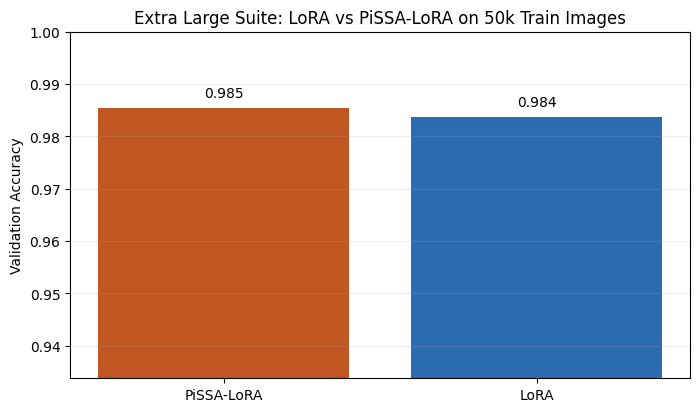

In [ ]:
extra_large_results = None

if RUN_EXTRA_LARGE_SUITE:
    extra_large_results = run_suite(
        EXTRA_LARGE_CONFIG,
        include_full_ft=RUN_FULL_FT_IN_EXTRA_LARGE
    )
    plot_suite(
        extra_large_results,
        "Extra Large Suite: LoRA vs PiSSA-LoRA on 50k Train Images"
    )
else:
    print("Extra large suite skipped.")


In [ ]:
stamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# save this run by itself
if isinstance(extra_large_results, pd.DataFrame):
    extra_large_path = OUTPUT_DIR / f"{EXTRA_LARGE_CONFIG.name}_{stamp}.csv"
    extra_large_results.to_csv(extra_large_path, index=False)
    print("saved extra-large:", extra_large_path)

# save combined results from any suites you ran
frames = [df for df in [quick_results, large_results, extra_large_results] if isinstance(df, pd.DataFrame)]
all_results = pd.concat(frames, ignore_index=True)

all_results["setup"] = (
    all_results["train_size"].astype(str)
    + " train / "
    + all_results["val_size"].astype(str)
    + " val"
)

combined_path = OUTPUT_DIR / f"all_results_{stamp}.csv"
all_results.to_csv(combined_path, index=False)

display(all_results.round(4))
print("saved combined:", combined_path)


saved extra-large: /content/drive/MyDrive/ece570_cp2_outputs/extra_large_50k_e3_eb128_20260329_230032.csv


,suite,method,method_label,init_used,train_size,val_size,epochs,micro_batch_size,eval_batch_size,grad_accum_steps,...,max_eval_batches,trainable_params,total_params,trainable_pct,val_loss_before,val_acc_before,train_loss_last,val_loss_after,val_acc_after,setup
0,quick_ablation,pissa_lora,PiSSA-LoRA,pissa_niter_4,5000,1000,1,16,64,2,...,None,302602,86108948,0.3514,2.3286,0.0700,1.5333,0.6549,0.9640,5000 train / 1000 val
1,quick_ablation,lora,LoRA,True,5000,1000,1,16,64,2,...,None,302602,86108948,0.3514,2.3286,0.0700,1.5104,0.5902,0.9620,5000 train / 1000 val
2,quick_ablation,full_ft,Full FT,full_ft,5000,1000,1,16,64,2,...,None,85806346,85806346,100.0000,2.3286,0.0700,1.0338,0.4180,0.9450,5000 train / 1000 val
3,large_50k,pissa_lora,PiSSA-LoRA,pissa_niter_4,50000,10000,1,16,64,2,...,None,302602,86108948,0.3514,2.3260,0.0739,0.2502,0.0573,0.9834,50000 train / 10000 val
4,large_50k,lora,LoRA,True,50000,10000,1,16,64,2,...,None,302602,86108948,0.3514,2.3260,0.0737,0.2462,0.0616,0.9822,50000 train / 10000 val
5,extra_large_50k_e3_eb128,pissa_lora,PiSSA-LoRA,pissa_niter_4,50000,10000,3,32,128,4,...,None,302602,86108948,0.3514,2.3261,0.0739,0.0258,0.0537,0.9854,50000 train / 10000 val
6,extra_large_50k_e3_eb128,lora,LoRA,True,50000,10000,3,32,128,4,...,None,302602,86108948,0.3514,2.3261,0.0737,0.0377,0.0595,0.9838,50000 train / 10000 val


saved combined: /content/drive/MyDrive/ece570_cp2_outputs/all_results_20260329_230032.csv
